In [1]:
# TITANIC DATASET ANALYSIS

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

In [4]:
print("First 5 Records")
print(df.head())

First 5 Records
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   N

In [5]:
print("\nDataset Shape")
print(df.shape)


Dataset Shape
(891, 12)


In [6]:
print("\nColumn Names")
print(df.columns)


Column Names
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [7]:
print("\nData Types")
print(df.dtypes)


Data Types
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object


In [8]:
print("\nMissing Values")
print(df.isnull().sum())


Missing Values
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
print("\nStatistical Summary")
print(df.describe())


Statistical Summary
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


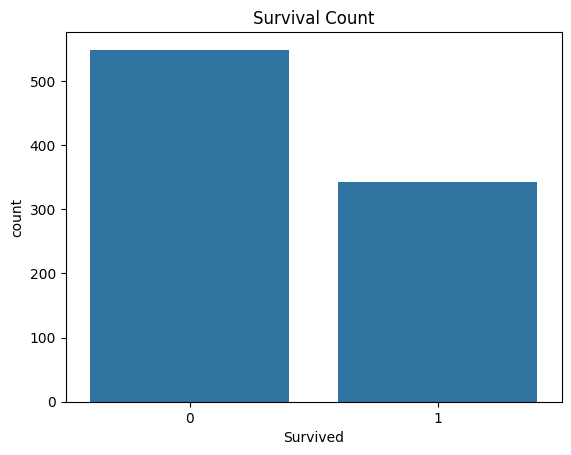

In [10]:
# Survival Count
sns.countplot(x='Survived', data=df)
plt.title("Survival Count")
plt.show()

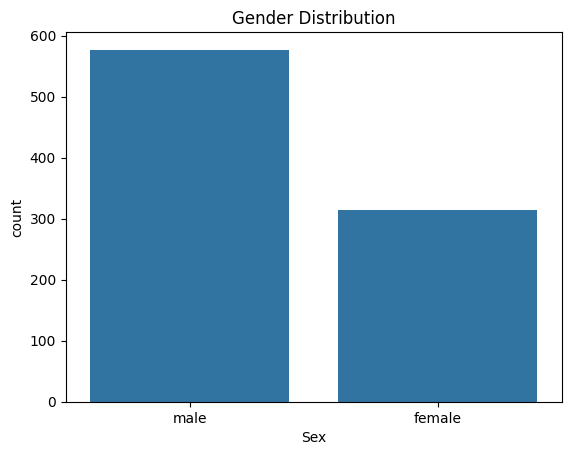

In [11]:
# Gender Count
sns.countplot(x='Sex', data=df)
plt.title("Gender Distribution")
plt.show()

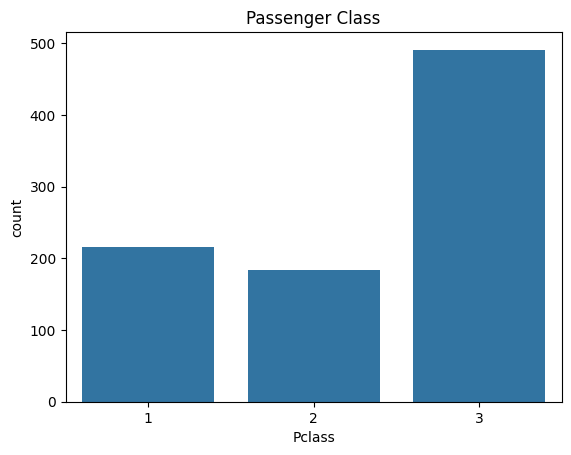

In [12]:
# Passenger Class
sns.countplot(x='Pclass', data=df)
plt.title("Passenger Class")
plt.show()

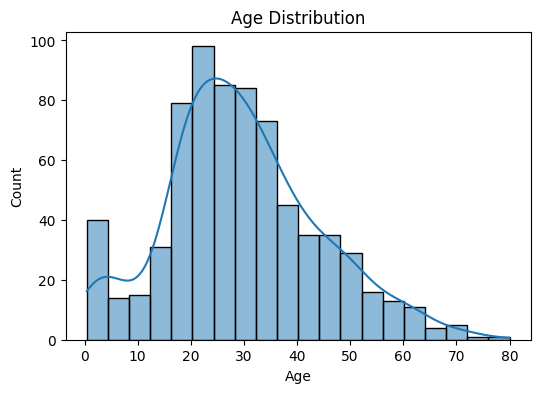

In [13]:
# Age Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

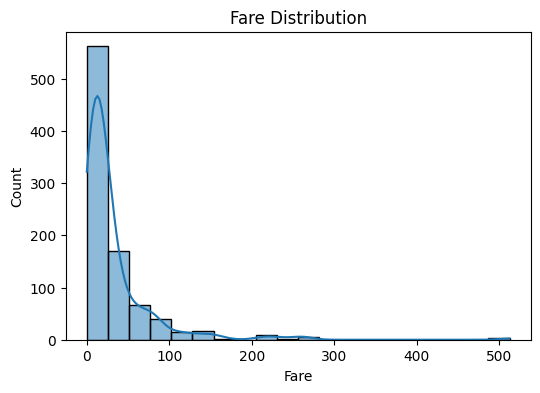

In [14]:
# Fare Distribution
plt.figure(figsize=(6,4))
sns.histplot(df['Fare'], bins=20, kde=True)
plt.title("Fare Distribution")
plt.show()

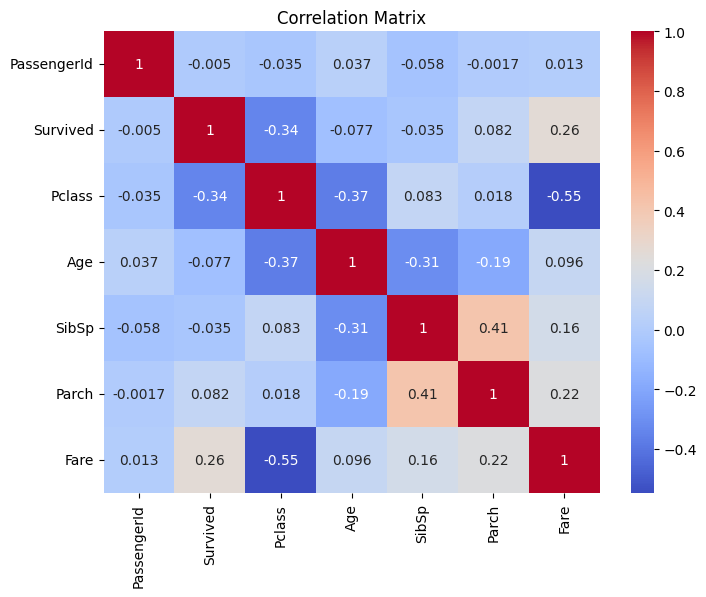

In [25]:
# Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [17]:
print("\nNumeric Attributes")
numeric = df.select_dtypes(include=['int64','float64']).columns
print(numeric)


Numeric Attributes
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


In [18]:
print("\nNominal Attributes")
nominal = ['Sex','Embarked']
print(nominal)


Nominal Attributes
['Sex', 'Embarked']


In [19]:
print("\nBinary Attributes")
binary = ['Survived']
print(binary)


Binary Attributes
['Survived']


In [20]:
#dissmilarity for nomial attributes
sex = df['Sex']
embarked = df['Embarked']

count = 0
total = 0

for s,e in zip(sex,embarked):

    if pd.isna(s) or pd.isna(e):
        continue

    total += 1

    if s != e:
        count += 1

dissimilarity = count/total

print("\nNominal Attribute Dissimilarity")
print("Sex vs Embarked =", dissimilarity)



Nominal Attribute Dissimilarity
Sex vs Embarked = 1.0


In [21]:
# Remove Missing Values

temp = df[['Age','Fare']].dropna()

age = temp.iloc[0]['Age']
fare = temp.iloc[0]['Fare']
age2 = temp.iloc[1]['Age']
fare2 = temp.iloc[1]['Fare']
distance = np.sqrt((age-age2)**2 + (fare-fare2)**2)
print("\nEuclidean Distance")
print(distance)


Euclidean Distance
66.00199624928021


In [22]:
manhattan = abs(age-age2)+abs(fare-fare2)
print("\nManhattan Distance")
print(manhattan)


Manhattan Distance
80.0333


In [23]:
minkowski=((abs(age-age2)**3)+(abs(fare-fare2)**3))**(1/3)
print("\nMinkowski Distance")
print(minkowski)


Minkowski Distance
64.36456998082116


In [24]:
#cosine dissmilarity
A=np.array([age,fare])
B=np.array([age2,fare2])
cosine_similarity=np.dot(A,B)/(np.linalg.norm(A)*np.linalg.norm(B))
cosine_dissimilarity=1-cosine_similarity
print("\nCosine Dissimilarity")
print(cosine_dissimilarity)


Cosine Dissimilarity
0.2770235351726641
